# Netflix Titles Dataset – Exploratory Analysis & Insights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### step 1 - load the netflix dataset

In [2]:
df = pd.read_csv(r"C:\Users\ACS\Downloads\archive (3)\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("rows:", df.shape[0])
print("columns:", df.shape[1])

rows: 8807
columns: 12


### Step 2 — understand the dataset before cleaning it

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### step 3 - handling missing values

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [10]:
df['rating'] = df['rating'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')

In [11]:
df["date_added"] = pd.to_datetime(df["date_added"], errors='coerce')

In [12]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [13]:
df[df["date_added"].isna()][["title", "date_added"]].head(20)

,title,date_added
6066,A Young Doctor's Notebook and Other Stories,NaT
6079,Abnormal Summit,NaT
6174,Anthony Bourdain: Parts Unknown,NaT
6177,忍者ハットリくん,NaT
6213,Bad Education,NaT
6279,Being Mary Jane: The Series,NaT
6304,"Big Dreams, Small Spaces",NaT
6318,Bitten,NaT
6357,Bondi Rescue,NaT
6361,Borderline,NaT


### step 4 - Handle the missing date_added

In [18]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [19]:
print(df["date_added"].dtype)

datetime64[ns]


In [25]:
df = pd.read_csv(r"C:\Users\ACS\Downloads\archive (3)\netflix_titles.csv")
df["date_added"].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

### step 5 - clean the data column correctly

In [26]:
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

In [28]:
print(df["date_added"].dtype)

datetime64[ns]


### step 6 - create data features

In [29]:
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

In [30]:
df[["title", "date_added", "added_year", "added_month"]].head()

,title,date_added,added_year,added_month
0,Dick Johnson Is Dead,2021-09-25,2021.0,9.0
1,Blood & Water,2021-09-24,2021.0,9.0
2,Ganglands,2021-09-24,2021.0,9.0
3,Jailbirds New Orleans,2021-09-24,2021.0,9.0
4,Kota Factory,2021-09-24,2021.0,9.0


In [31]:
#1.create release_decade
df["release_decade"] = (df["release_year"] // 10) * 10

In [32]:
#2. create is_movie
df["is_movie"] = df["type"].apply(lambda x: 1 if x == "Movie" else 0)

In [33]:
#3. check everything
df[["title", "release_year", "release_decade", "type", "is_movie"]].head(10)

,title,release_year,release_decade,type,is_movie
0,Dick Johnson Is Dead,2020,2020,Movie,1
1,Blood & Water,2021,2020,TV Show,0
2,Ganglands,2021,2020,TV Show,0
3,Jailbirds New Orleans,2021,2020,TV Show,0
4,Kota Factory,2021,2020,TV Show,0
5,Midnight Mass,2021,2020,TV Show,0
6,My Little Pony: A New Generation,2021,2020,Movie,1
7,Sankofa,1993,1990,Movie,1
8,The Great British Baking Show,2021,2020,TV Show,0
9,The Starling,2021,2020,Movie,1


In [34]:
#4. check the dataset structure
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 16


### step 7 - Analyze Movie vs TV Show

In [36]:
#1.first check the counts
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

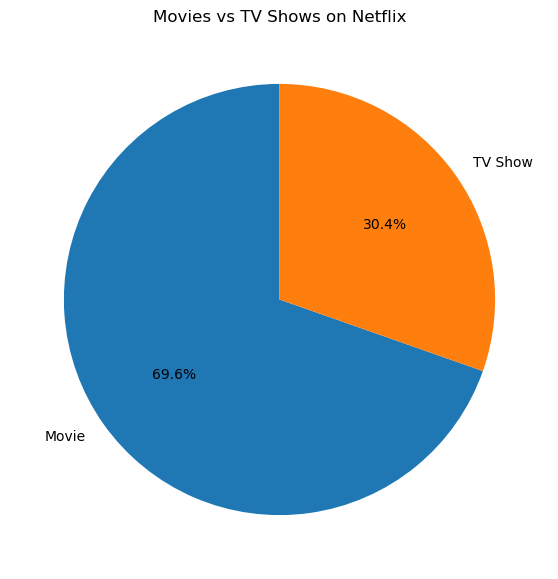

In [37]:
#2. create pie chart
plt.figure(figsize=(7, 7))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows on Netflix")
plt.ylabel("")
plt.show()

### step 8 - content released by year

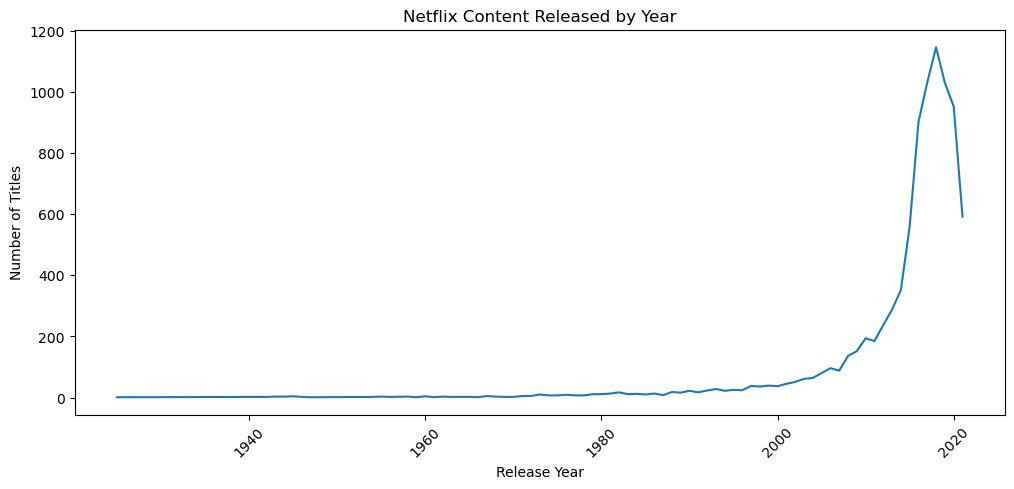

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_content.index,
    yearly_content.values
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### step 9 - top 10 genres

In [40]:
genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

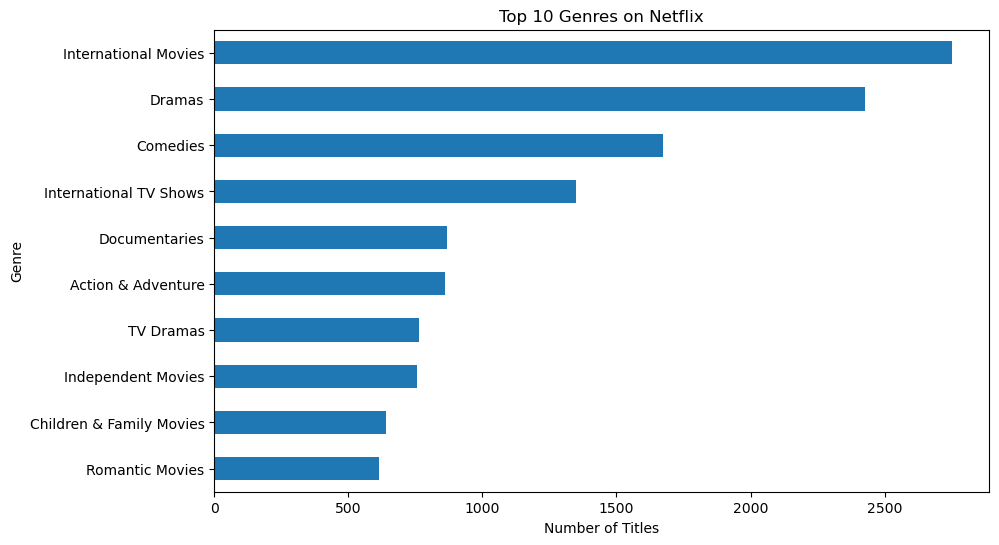

In [41]:
#create bar chart
plt.figure(figsize=(10, 6))

top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()


### step 10 - top 5 contries

In [42]:
countries = df["country"].str.split(", ").explode()

top_countries = countries.value_counts().head(5)

top_countries

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

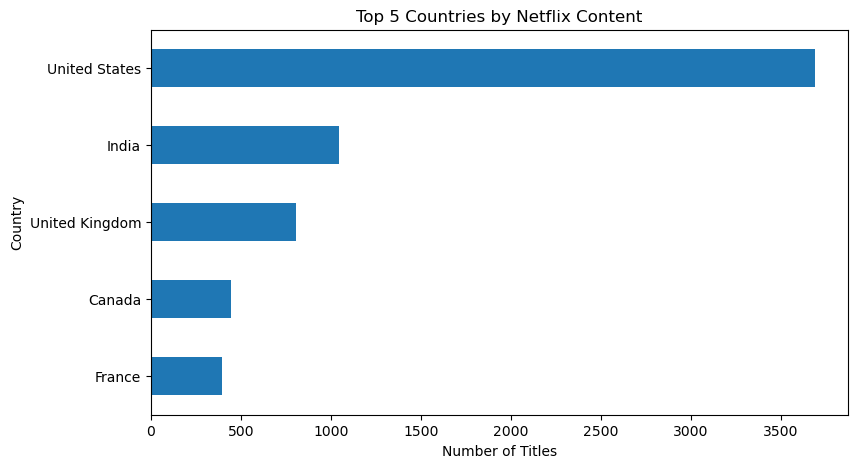

In [43]:
plt.figure(figsize=(9, 5))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 5 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### step 11 - Country vs Content Type

In [ ]:
#1.prepare the country data
country_type = df.copy()

country_type["country"] = country_type["country"].str.split(", ")

country_type = country_type.explode("country")

In [50]:
#2. keep the top 10 countries
top_10_countries = (
    country_type["country"]
    .value_counts()
    .head(10)
    .index
)

country_type_top = country_type[
    country_type["country"].isin(top_10_countries)
]

In [52]:
#Create the country × content-type table
country_content = pd.crosstab(
    country_type_top["country"],
    country_type_top["type"]
)

country_content

type,Movie,TV Show
country,,
Canada,319,126
France,303,90
Germany,182,44
India,962,84
Japan,119,199
Mexico,111,58
South Korea,61,170
Spain,171,61
United Kingdom,532,272


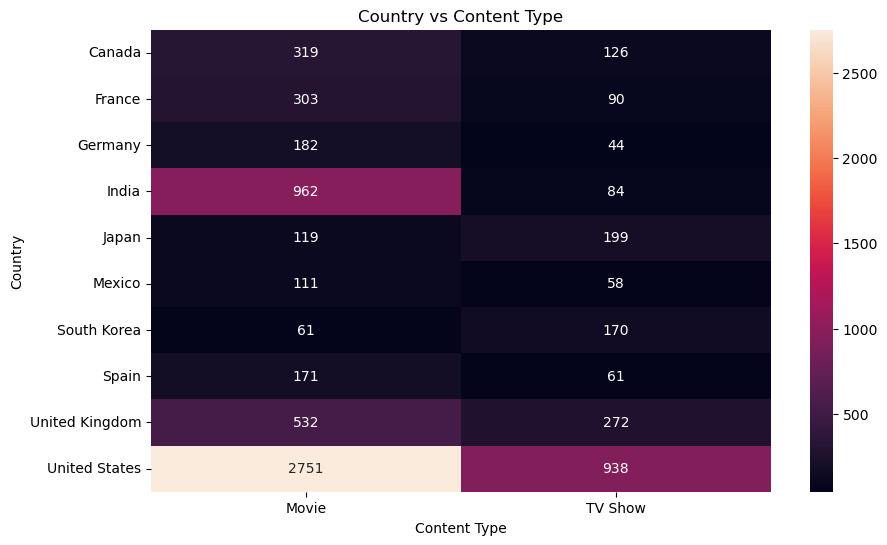

In [53]:
#create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    country_content,
    annot=True,
    fmt="d"
)

plt.title("Country vs Content Type")
plt.xlabel("Content Type")
plt.ylabel("Country")

plt.show()

## 6. Key Insights

### Insight 1 — Movies vs TV Shows
The Netflix dataset contains both movies and TV shows, with movies making up a larger share of the available titles.

**What does this mean?**  
Netflix has a broad movie-focused content library, while TV shows also represent an important part of its catalog.

### Insight 2 — Content Release Trend
The number of titles varies considerably across release years, with a strong concentration of titles from more recent years.

**What does this mean?**  
The catalog contains a substantial amount of relatively recent content, reflecting Netflix's focus on newer entertainment.

### Insight 3 — Popular Genres
The genre analysis shows that some genres occur much more frequently than others in the dataset.

**What does this mean?**  
Netflix's catalog is concentrated around several recurring genres rather than being evenly distributed across all genres.

### Insight 4 — Top Countries
The country analysis shows that a small number of countries contribute a large share of the available content.

**What does this mean?**  
Netflix's catalog has strong representation from particular content-producing countries, while many other countries contribute smaller amounts.

### Insight 5 — Country and Content Type
The country vs. content-type heatmap shows differences in the volume of movies and TV shows associated with different countries.

**What does this mean?**  
Content type is not distributed equally across countries; some countries contribute relatively more movies, while others have stronger TV-show representation.

### Insight 6 — Release Decades
The release-decade analysis shows how the Netflix catalog contains content from multiple decades, with newer decades contributing a substantial portion of the titles.

**What does this mean?**  
Netflix provides a combination of newer releases and older content, allowing users to access content from different periods.

#### step 1- Re-apply the missing-value cleaning

In [54]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

print(df.isnull().sum())

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
added_year        10
added_month       10
release_decade     0
is_movie           0
dtype: int64


#### Step 2 — Check duplicates

In [55]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Step 3 — Check the important features

In [56]:
print(df[[
    "type",
    "release_year",
    "release_decade",
    "is_movie",
    "date_added"
]].head())

      type  release_year  release_decade  is_movie date_added
0    Movie          2020            2020         1 2021-09-25
1  TV Show          2021            2020         0 2021-09-24
2  TV Show          2021            2020         0 2021-09-24
3  TV Show          2021            2020         0 2021-09-24
4  TV Show          2021            2020         0 2021-09-24


#### Step 4 — Get the actual numbers for our insights

In [57]:
print("CONTENT TYPE")
print(df["type"].value_counts())

print("\nTOP 10 GENRES")
print(top_genres)

print("\nTOP 5 COUNTRIES")
print(top_countries)

print("\nRECENT RELEASE YEARS")
print(yearly_content.tail(10))

CONTENT TYPE
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

TOP 10 GENRES
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

TOP 5 COUNTRIES
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

RECENT RELEASE YEARS
release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64
